In [1]:
import tensorflow as tf
from tensorflow import keras

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.optimizers import Adam
from keras.utils import to_categorical
from keras.applications import VGG16
from keras import backend as K

# Set seed value for NumPy
np.random.seed(42)

# Set seed value for TensorFlow
tf.random.set_seed(42)

In [3]:
# Load the training data
train_df = pd.read_csv("./Dataset/train.csv")

In [4]:
# Update the 'id_code' column to include the file extension
train_df['id_code'] = train_df['id_code'].astype(str) + ".png"

In [5]:
# Convert multiclass labels into binary labels
train_df['diagnosis_binary'] = train_df['diagnosis'].apply(lambda x: 0 if x == '0' else 1)
train_df['diagnosis_binary'] = train_df['diagnosis_binary'].astype(str)

In [7]:
# Convert multiclass labels into binary labels
# Here, '0' is mapped to 'No DR', and '1', '2', '3', '4' are mapped to 'DR'
train_df['diagnosis_binary'] = train_df['diagnosis'].apply(lambda x: '0' if x == 0 else '1')

In [9]:
# Display the first few rows of the dataframe
print(train_df.head())

            id_code  diagnosis diagnosis_binary
0  000c1434d8d7.png          2                1
1  001639a390f0.png          4                1
2  0024cdab0c1e.png          1                1
3  002c21358ce6.png          0                0
4  005b95c28852.png          0                0


In [10]:
# Display the first few rows of the dataframe
print(train_df.head(10))

            id_code  diagnosis diagnosis_binary
0  000c1434d8d7.png          2                1
1  001639a390f0.png          4                1
2  0024cdab0c1e.png          1                1
3  002c21358ce6.png          0                0
4  005b95c28852.png          0                0
5  0083ee8054ee.png          4                1
6  0097f532ac9f.png          0                0
7  00a8624548a9.png          2                1
8  00b74780d31d.png          2                1
9  00cb6555d108.png          1                1


In [11]:
# Split the data into training, validation, and hold-out test sets
train_data, test_data = train_test_split(train_df, test_size=0.2, random_state=42)
train_data, val_data = train_test_split(train_data, test_size=0.2, random_state=42)

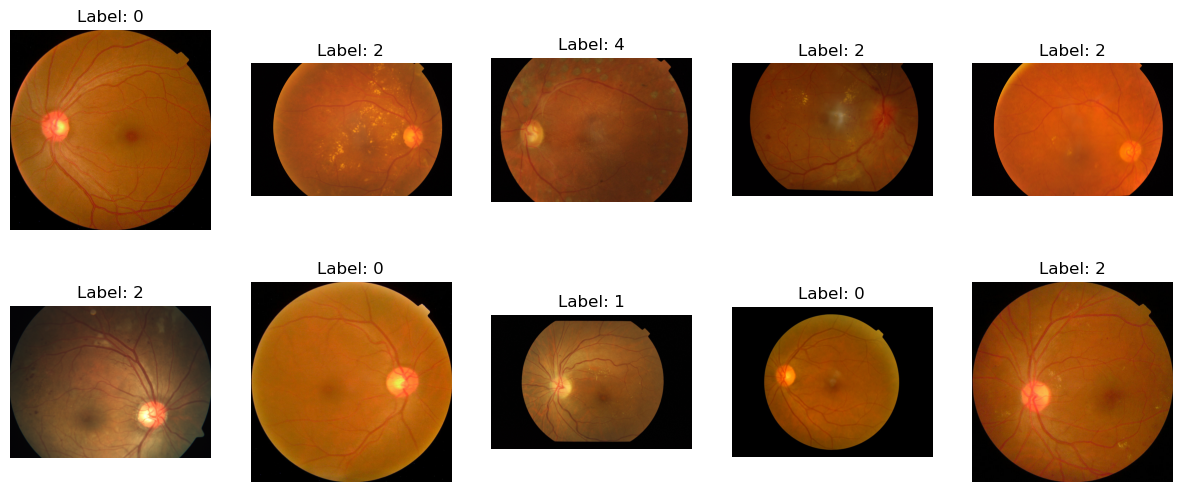

In [12]:
# Visualize a few original images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    img_path = f"./Dataset/train_images/{train_data['id_code'].iloc[i]}"
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {train_data['diagnosis'].iloc[i]}")

plt.show()

## Train Validation Generator

In [13]:
# Data preprocessing and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [14]:
val_datagen = ImageDataGenerator(rescale=1./255)

In [15]:
# Adjust the 'directory' parameter to match path to train images
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    directory="./Dataset/train_images/",
    x_col="id_code",
    y_col="diagnosis_binary",
    target_size=(256, 256),
    batch_size=32,
    class_mode="binary"
)

Found 2334 validated image filenames belonging to 2 classes.


C:\Users\MSI\anaconda3\envs\DataAnalytics\lib\site-packages\keras_preprocessing\image\dataframe_iterator.py:282: UserWarning: Found 9 invalid image filename(s) in x_col="id_code". These filename(s) will be ignored.
  .format(n_invalid, x_col)


In [16]:
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_data,
    directory="./Dataset/train_images/",
    x_col="id_code",
    y_col="diagnosis_binary",
    target_size=(256, 256),
    batch_size=32,
    class_mode="binary"
)

Found 583 validated image filenames belonging to 2 classes.


C:\Users\MSI\anaconda3\envs\DataAnalytics\lib\site-packages\keras_preprocessing\image\dataframe_iterator.py:282: UserWarning: Found 3 invalid image filename(s) in x_col="id_code". These filename(s) will be ignored.
  .format(n_invalid, x_col)


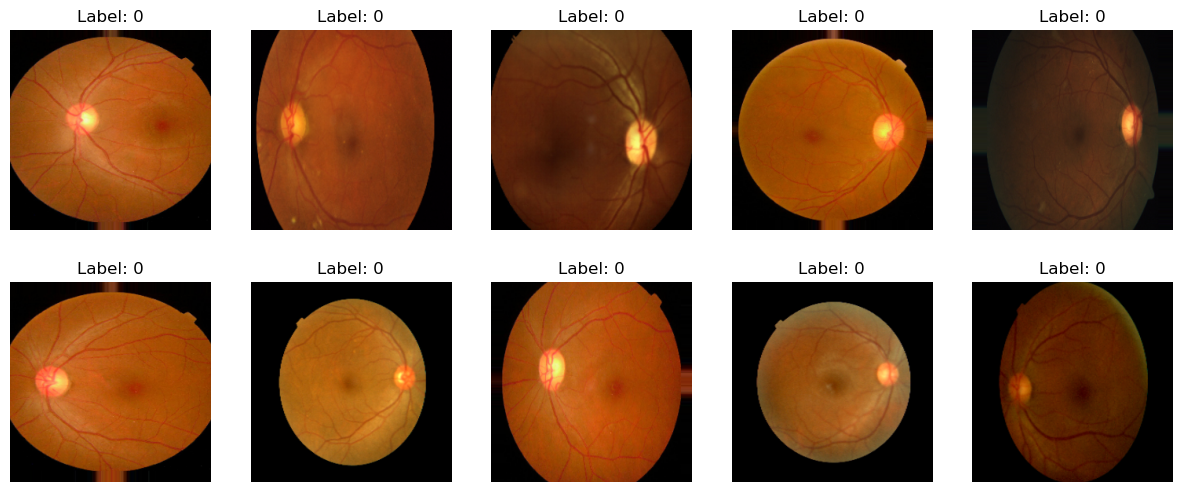

In [17]:
# Visualize a few augmented train images after pre-processing
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    img, label = train_generator.next()
    ax.imshow(img[0])
    ax.axis('off')
    ax.set_title(f"Label: {np.argmax(label[0])}")

plt.show()

## Build CNN Model

In [18]:
# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [19]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 254, 254, 32)      896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 127, 127, 32)      0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 125, 125, 64)      18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 62, 62, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 60, 60, 128)       73856     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 30, 30, 128)       0         
_________________________________________________________________
flatten (Flatten)            (None, 115200)            0

In [20]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [21]:
# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.n // train_generator.batch_size,
    epochs=50,
    validation_data=val_generator,
    validation_steps=val_generator.n // val_generator.batch_size,
    callbacks=[early_stop]
)

Epoch 1/50
72/72 [==============================] - 425s 6s/step - loss: 0.5347 - accuracy: 0.7459 - val_loss: 0.2692 - val_accuracy: 0.8889
Epoch 2/50
72/72 [==============================] - 335s 5s/step - loss: 0.3247 - accuracy: 0.8736 - val_loss: 0.1919 - val_accuracy: 0.9097
Epoch 3/50
72/72 [==============================] - 328s 5s/step - loss: 0.2572 - accuracy: 0.9083 - val_loss: 0.1793 - val_accuracy: 0.9323
Epoch 4/50
72/72 [==============================] - 345s 5s/step - loss: 0.2456 - accuracy: 0.9131 - val_loss: 0.1619 - val_accuracy: 0.9392
Epoch 5/50
72/72 [==============================] - 331s 5s/step - loss: 0.2364 - accuracy: 0.9183 - val_loss: 0.1935 - val_accuracy: 0.9149
Epoch 6/50
72/72 [==============================] - 330s 5s/step - loss: 0.2426 - accuracy: 0.9175 - val_loss: 0.1765 - val_accuracy: 0.9392
Epoch 7/50
72/72 [==============================] - 327s 5s/step - loss: 0.2348 - accuracy: 0.9231 - val_loss: 0.1658 - val_accuracy: 0.9444
Epoch 8/50
72

In [22]:
print("Model evalution result --> Training Data")
model.evaluate(train_generator)

Model evalution result --> Training Data
73/73 [==============================] - 228s 3s/step - loss: 0.1038 - accuracy: 0.9636


[0.10375473648309708, 0.9635818600654602]

In [23]:
print("Model evalution result --> Validation Data")
model.evaluate(val_generator)

Model evalution result --> Validation Data
19/19 [==============================] - 50s 3s/step - loss: 0.1169 - accuracy: 0.9571


[0.11692268401384354, 0.9571183323860168]

In [24]:
model.save("RetionagraphyDetectV3Binary.h5")
print(">> MODEL SAVED")

>> MODEL SAVED


## Training Validation Accuracy and Loss

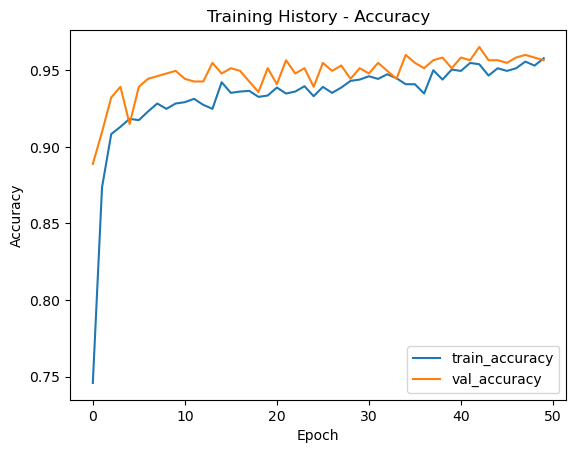

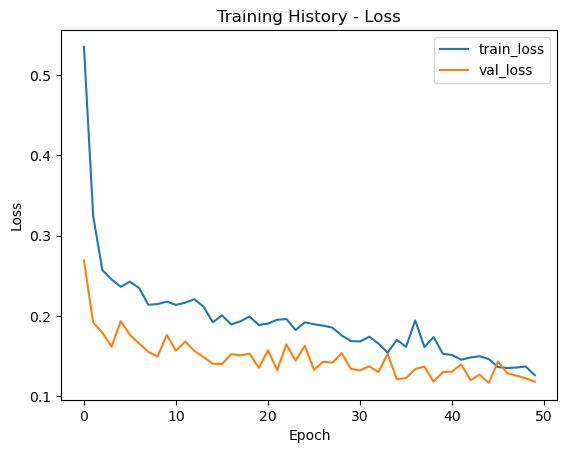

In [25]:
# Visualize training history
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Training History - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Training History - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [26]:
from sklearn.metrics import roc_auc_score

## Test the Model

In [27]:
# Load the test data
test_datagen = ImageDataGenerator(rescale=1./255)

In [28]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_data,
    directory="./Dataset/train_images/",
    x_col="id_code",
    y_col="diagnosis_binary",
    target_size=(256, 256),
    batch_size=32,
    class_mode="binary",
    shuffle=False  # Ensure the same order as in test_data
)

Found 731 validated image filenames belonging to 2 classes.


C:\Users\MSI\anaconda3\envs\DataAnalytics\lib\site-packages\keras_preprocessing\image\dataframe_iterator.py:282: UserWarning: Found 2 invalid image filename(s) in x_col="id_code". These filename(s) will be ignored.
  .format(n_invalid, x_col)


In [29]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.n // test_generator.batch_size)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_acc}")

22/22 [==============================] - 104s 5s/step - loss: 0.1742 - accuracy: 0.9446
Test Loss: 0.17421230673789978, Test Accuracy: 0.9446022510528564


In [30]:
# Make predictions on the test set
predictions = model.predict(test_generator)

In [31]:
# Calculate AUC-ROC score
y_true = test_generator.classes
y_score = predictions.ravel()  # Flatten predictions
auc_roc = roc_auc_score(y_true, y_score)
print(f"AUC-ROC Score: {auc_roc}")

AUC-ROC Score: 0.9838806462743216


## Confusion Matrix

In [33]:
from sklearn.metrics import confusion_matrix, classification_report

# Convert predicted probabilities to binary predictions
y_pred_binary = (y_score > 0.5).astype(int)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_binary)
print("Confusion Matrix:")
print(conf_matrix)

# Generate classification report
class_report = classification_report(y_true, y_pred_binary)
print("\nClassification Report:")
print(class_report)


Confusion Matrix:
[[336  13]
 [ 28 354]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       349
           1       0.96      0.93      0.95       382

    accuracy                           0.94       731
   macro avg       0.94      0.94      0.94       731
weighted avg       0.94      0.94      0.94       731



In [35]:
pip install seaborn

     -------------------------------------- 293.3/293.3 kB 1.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


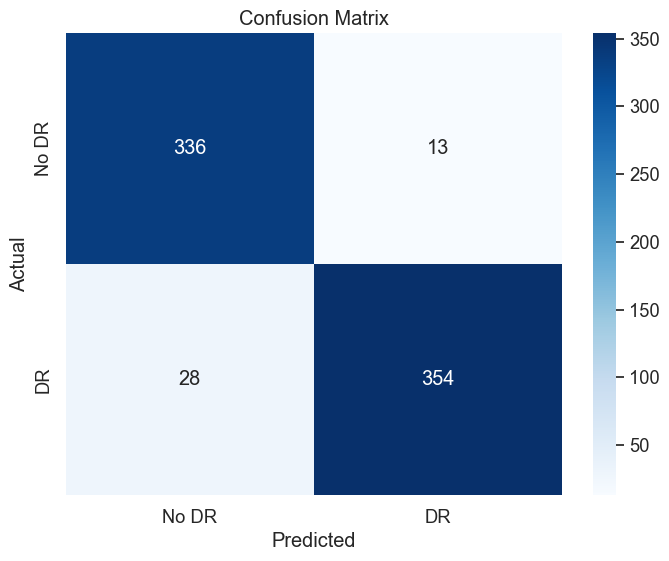

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Rename classes
class_names = ["No DR", "DR"]

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_binary)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


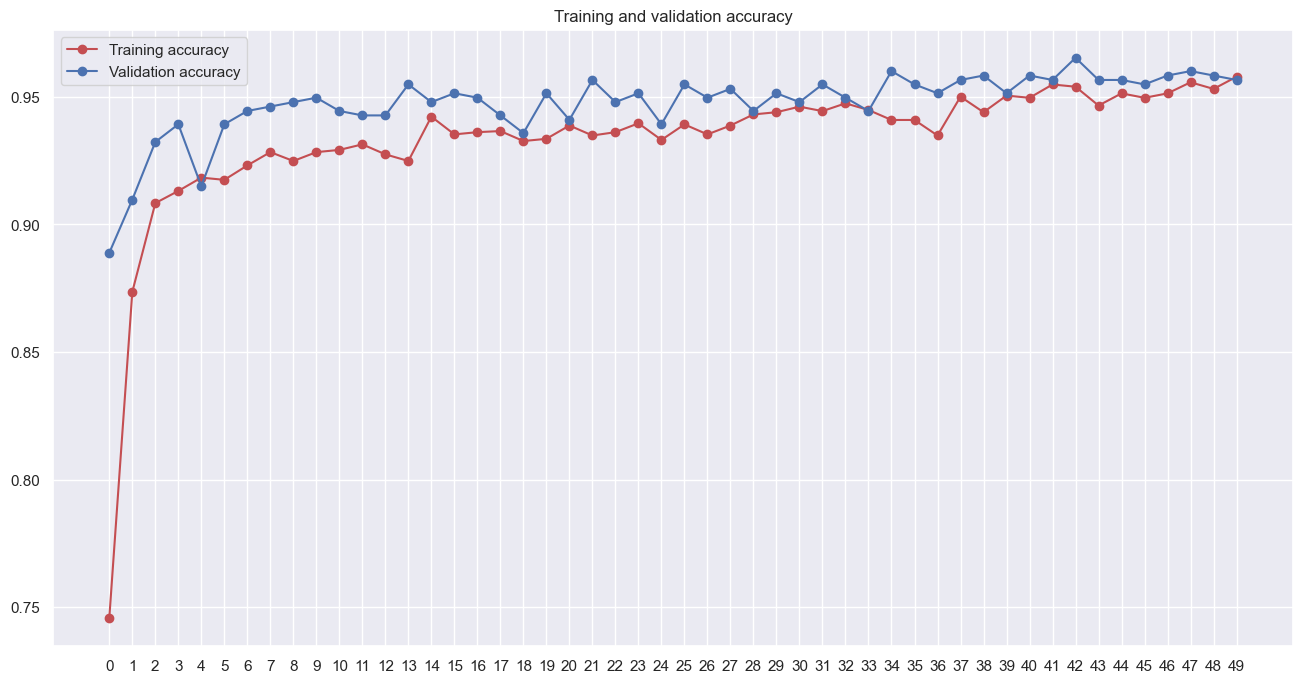

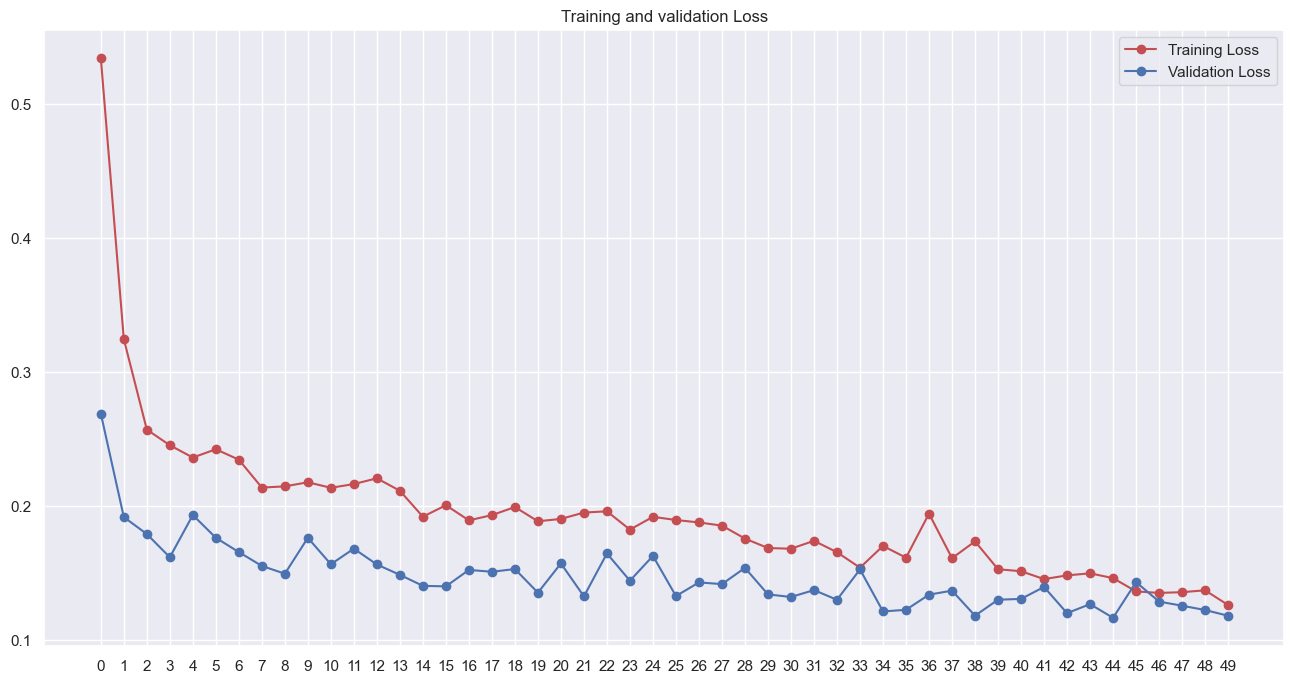

<Figure size 640x480 with 0 Axes>

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(0,len(acc))
fig = plt.gcf()
fig.set_size_inches(16, 8)

plt.plot(epochs, acc, 'r', label='Training accuracy',marker = "o")
plt.plot(epochs, val_acc, 'b', label='Validation accuracy',marker = "o")
plt.title('Training and validation accuracy')
plt.xticks(np.arange(0, len(acc), 1))
plt.plot(labels="Total Epochs")
plt.legend(loc=0)
plt.figure()

fig = plt.gcf()
fig.set_size_inches(16, 8)
plt.plot(epochs, loss, 'r', label='Training Loss',marker = "o")
plt.plot(epochs, val_loss, 'b', label='Validation Loss',marker = "o")
plt.title('Training and validation Loss')
plt.xticks(np.arange(0, len(acc), 1))
plt.plot(labels="Total Epochs")
plt.legend(loc=0)

plt.figure()
plt.show()

## Run the model again

In [39]:
import tensorflow as tf

def binary_smooth_loss(y_true, y_pred, label_smoothing=0.1):
    y_true = tf.cast(y_true, y_pred.dtype)  # Ensure data types match
    smooth_positives = 1.0 - label_smoothing
    smooth_negatives = label_smoothing / 2.0
    
    # Smoothed labels
    smooth_positives_true = y_true * smooth_positives
    smooth_negatives_true = (1.0 - y_true) * smooth_negatives
    
    # Combine smoothed labels
    y_true_smooth = smooth_positives_true + smooth_negatives_true
    
    # Calculate binary cross-entropy with smoothed labels
    loss = tf.keras.losses.binary_crossentropy(y_true_smooth, y_pred)
    return loss


In [38]:
lr_reduce = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, min_delta=0.0002, patience=3, verbose=1)

In [40]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [41]:
# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.n // train_generator.batch_size,
    epochs=20,
    validation_data=val_generator,
    validation_steps=val_generator.n // val_generator.batch_size,
    callbacks=[lr_reduce, early_stop]
)

Epoch 1/20
72/72 [==============================] - 348s 5s/step - loss: 0.1415 - accuracy: 0.9531 - val_loss: 0.1239 - val_accuracy: 0.9549
Epoch 2/20
72/72 [==============================] - 354s 5s/step - loss: 0.1275 - accuracy: 0.9531 - val_loss: 0.1327 - val_accuracy: 0.9583
Epoch 3/20
72/72 [==============================] - 355s 5s/step - loss: 0.1314 - accuracy: 0.9548 - val_loss: 0.1343 - val_accuracy: 0.9601
Epoch 4/20
72/72 [==============================] - ETA: 0s - loss: 0.1353 - accuracy: 0.9535
Epoch 00004: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
72/72 [==============================] - 373s 5s/step - loss: 0.1353 - accuracy: 0.9535 - val_loss: 0.1289 - val_accuracy: 0.9618
Epoch 5/20
72/72 [==============================] - 327s 5s/step - loss: 0.1197 - accuracy: 0.9583 - val_loss: 0.1193 - val_accuracy: 0.9635
Epoch 6/20
72/72 [==============================] - 328s 5s/step - loss: 0.1168 - accuracy: 0.9574 - val_loss: 0.1155 - val_accuracy

In [42]:
print("Model evalution result --> Training Data")
model.evaluate(train_generator)

Model evalution result --> Training Data
73/73 [==============================] - 253s 3s/step - loss: 0.0628 - accuracy: 0.9760


[0.0628291666507721, 0.9760068655014038]

In [43]:
print("Model evalution result --> Validation Data")
model.evaluate(val_generator)

Model evalution result --> Validation Data
19/19 [==============================] - 54s 3s/step - loss: 0.1077 - accuracy: 0.9640


[0.1076640635728836, 0.9639794230461121]

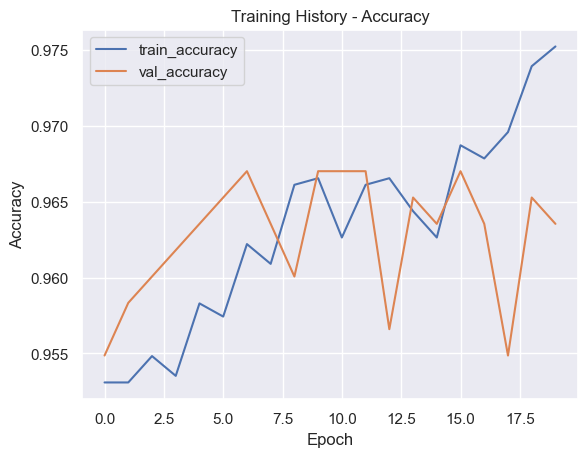

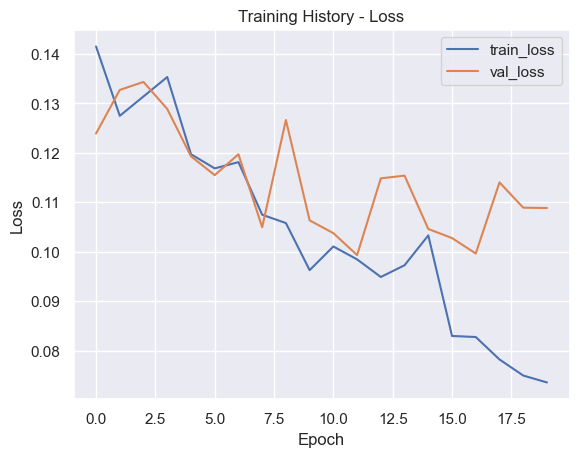

In [44]:
# Visualize training history
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Training History - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Training History - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [45]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.n // test_generator.batch_size)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_acc}")

22/22 [==============================] - 62s 3s/step - loss: 0.1701 - accuracy: 0.9489
Test Loss: 0.1700873225927353, Test Accuracy: 0.9488636255264282


In [47]:
# Make predictions on the test set
predictions = model.predict(test_generator)

In [48]:
# Calculate AUC-ROC score
y_true = test_generator.classes
y_score = predictions.ravel()  # Flatten predictions
auc_roc = roc_auc_score(y_true, y_score)
print(f"AUC-ROC Score: {auc_roc}")

AUC-ROC Score: 0.9861271546227816


In [49]:
from sklearn.metrics import confusion_matrix, classification_report

# Convert predicted probabilities to binary predictions
y_pred_binary = (y_score > 0.5).astype(int)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_binary)
print("Confusion Matrix:")
print(conf_matrix)

# Generate classification report
class_report = classification_report(y_true, y_pred_binary)
print("\nClassification Report:")
print(class_report)


Confusion Matrix:
[[335  14]
 [ 25 357]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       349
           1       0.96      0.93      0.95       382

    accuracy                           0.95       731
   macro avg       0.95      0.95      0.95       731
weighted avg       0.95      0.95      0.95       731



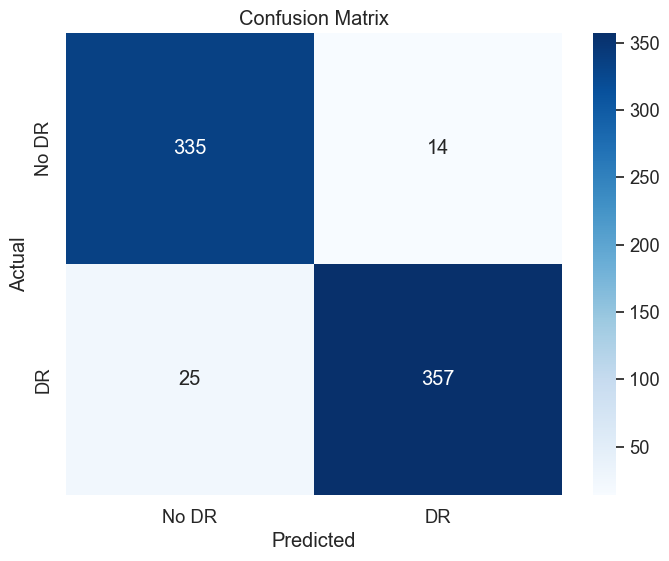

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Rename classes
class_names = ["No DR", "DR"]

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_binary)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

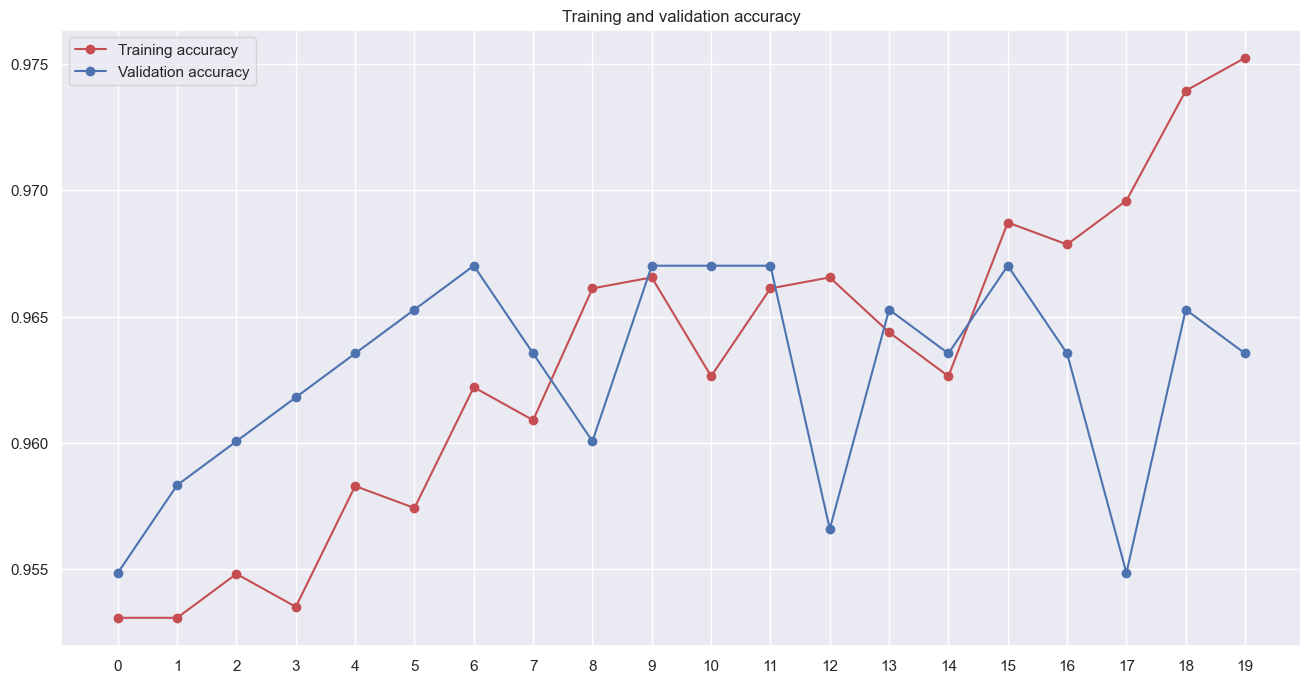

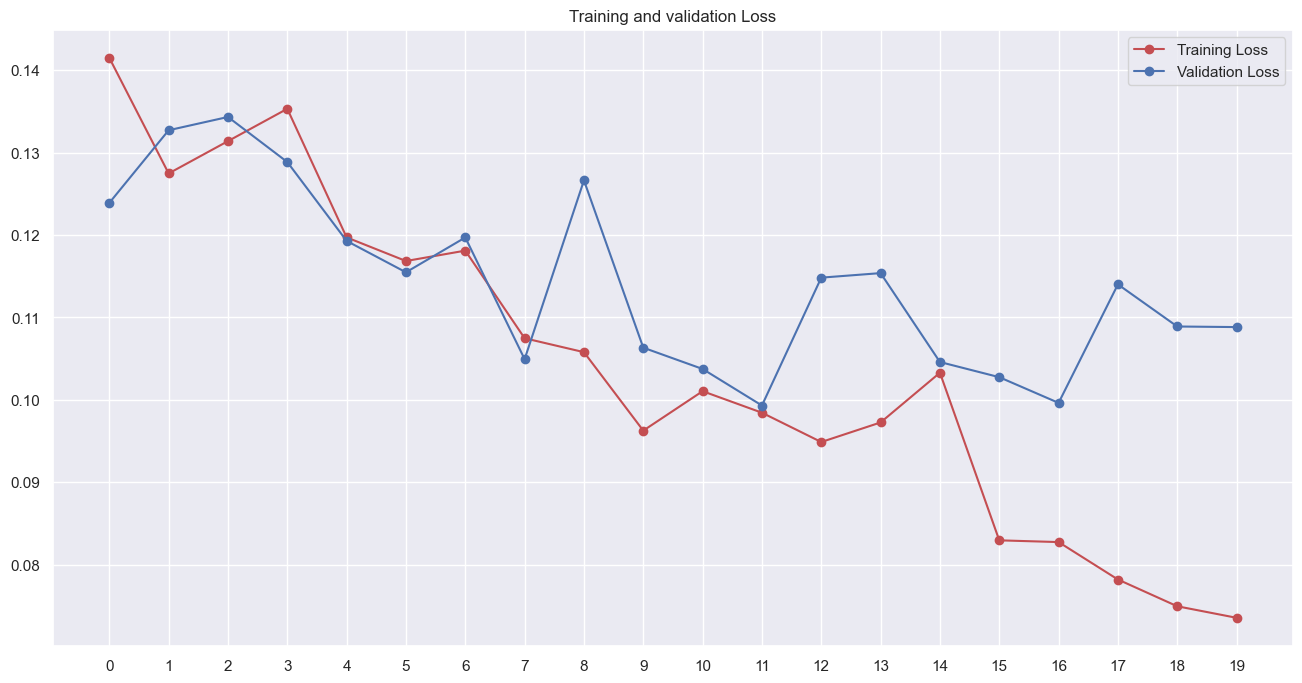

<Figure size 640x480 with 0 Axes>

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(0,len(acc))
fig = plt.gcf()
fig.set_size_inches(16, 8)

plt.plot(epochs, acc, 'r', label='Training accuracy',marker = "o")
plt.plot(epochs, val_acc, 'b', label='Validation accuracy',marker = "o")
plt.title('Training and validation accuracy')
plt.xticks(np.arange(0, len(acc), 1))
plt.plot(labels="Total Epochs")
plt.legend(loc=0)
plt.figure()

fig = plt.gcf()
fig.set_size_inches(16, 8)
plt.plot(epochs, loss, 'r', label='Training Loss',marker = "o")
plt.plot(epochs, val_loss, 'b', label='Validation Loss',marker = "o")
plt.title('Training and validation Loss')
plt.xticks(np.arange(0, len(acc), 1))
plt.plot(labels="Total Epochs")
plt.legend(loc=0)

plt.figure()
plt.show()